In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the data set

df = pd.read_csv('house_price.csv')
df.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB


### Q1. 
Perform basic EDA (Exploratory Data Analysis)

In [7]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,112.276178,2.800833,7.920337e+03
std,1237.323445,1.338915,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.267000e+03
50%,1275.000000,2.000000,71.850000,3.000000,5.438000e+03
75%,1672.000000,3.000000,120.000000,3.000000,7.317000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [9]:
df.isnull().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [11]:
df['price_per_sqft'].describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

### Q2. 
Detect the outliers using following methods and remove it using methods like trimming / capping/ imputation using mean or median  
a) Mean and Standard deviation  
b) Percentile method  
c) IQR(Inter quartile range method)  
d) Z Score method

C:\Users\USER\AppData\Local\Temp\ipykernel_9168\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

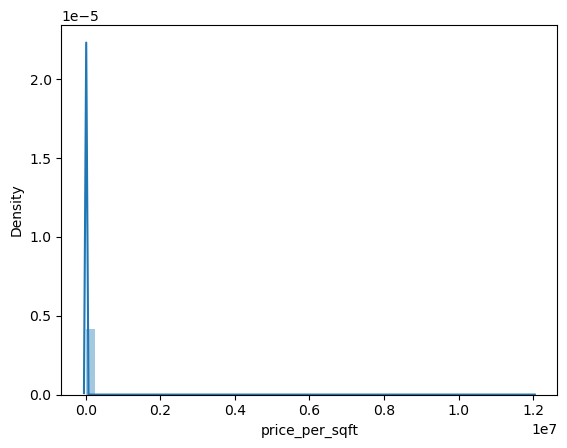

In [15]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

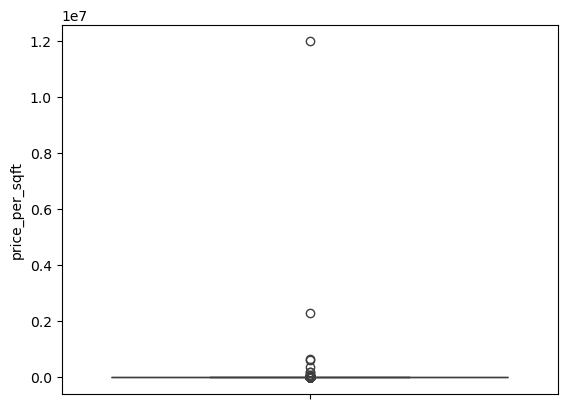

In [17]:
sns.boxplot(df['price_per_sqft'])

### (a): Mean and Standard Deviation

In [23]:
# Detect outliers using Mean and STD
mean_pps = df['price_per_sqft'].mean()
std_pps = df['price_per_sqft'].std()

# define outlier limits
upper_limit = mean_pps + 3 * std_pps
lower_limit = mean_pps - 3 * std_pps
print('Upper limit:',upper_limit)
print('Lower limit:',lower_limit)

Upper limit: 328101.8177267496
Lower limit: -312261.1442419011


In [25]:
# Detect the outliers
outliers_std_method = df[(df['price_per_sqft'] > upper_limit) | (df['price_per_sqft'] < lower_limit)]
outliers_std_method

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000
11447,Whitefield,4 Bedroom,60.0,4.0,218.0,4,363333


In [29]:
print('Outliers:',len(outliers_std_method))

Outliers: 5


In [55]:
# Remove outliers using Trimming

df_trimmed = df.loc[(df['price_per_sqft'] >= lower_limit) & (df['price_per_sqft'] <= upper_limit)]

In [57]:
print('before removing outliers:',len(df))
print('After removing outliers:',len(df_trimmed))
print('Outliers:',len(outliers_std_method))

before removing outliers: 13200
After removing outliers: 13195
Outliers: 5


<Axes: ylabel='price_per_sqft'>

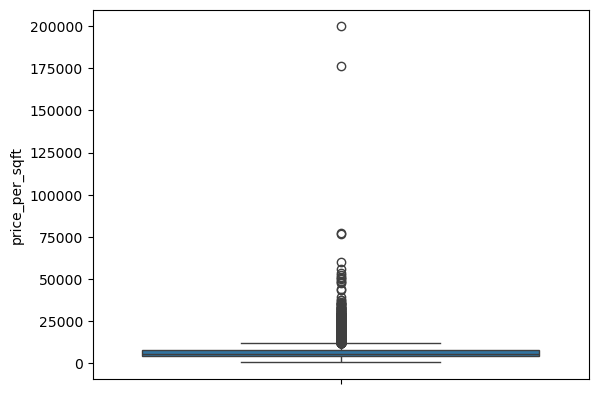

In [59]:
sns.boxplot(df_trimmed['price_per_sqft'])

In [73]:
# Removing outliers using Capping

capping_df = df.copy()
capping_df.loc[(capping_df['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit
capping_df.loc[(capping_df['price_per_sqft']<lower_limit), 'price_per_sqft'] = lower_limit

C:\Users\USER\AppData\Local\Temp\ipykernel_9168\3236851943.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '328101.8177267496' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  capping_df.loc[(capping_df['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit


<Axes: ylabel='price_per_sqft'>

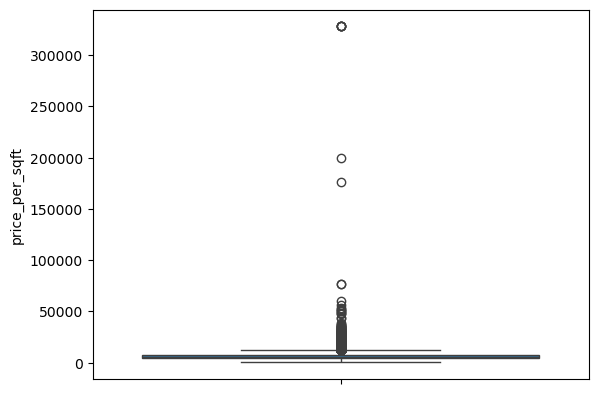

In [75]:
sns.boxplot(capping_df['price_per_sqft'])

### (b): IQR Method

In [84]:
# Detect outliers using IQR method

q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)
IQR = q3 - q1

In [90]:
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

In [101]:
# Find outliers
outliers_iqr = df.loc[(df['price_per_sqft'] < lower_limit) | (df['price_per_sqft'] > upper_limit)]
outliers_iqr

,location,size,total_sqft,bath,price,bhk,price_per_sqft
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.0,4,18181
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274
22,Thanisandra,4 Bedroom,2800.0,5.0,380.0,4,13571
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333
48,KR Puram,2 Bedroom,800.0,1.0,130.0,2,16250
...,...,...,...,...,...,...,...
13142,other,2 BHK,1140.0,1.0,185.0,2,16228
13157,other,7 Bedroom,1400.0,7.0,218.0,7,15571
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000
13186,other,4 Bedroom,1200.0,5.0,325.0,4,27083


In [99]:
print('Outliers:',len(outliers_iqr))

Outliers: 1265


In [107]:
# Remove outliers using Trimming

df_trimmed = df.loc[(df['price_per_sqft'] >= lower_limit) & (df['price_per_sqft'] <= upper_limit)]

In [109]:
print('before removing outliers:',len(df))
print('After removing outliers:',len(df_trimmed))
print('Outliers:',len(outliers_iqr))

before removing outliers: 13200
After removing outliers: 11935
Outliers: 1265


<Axes: ylabel='price_per_sqft'>

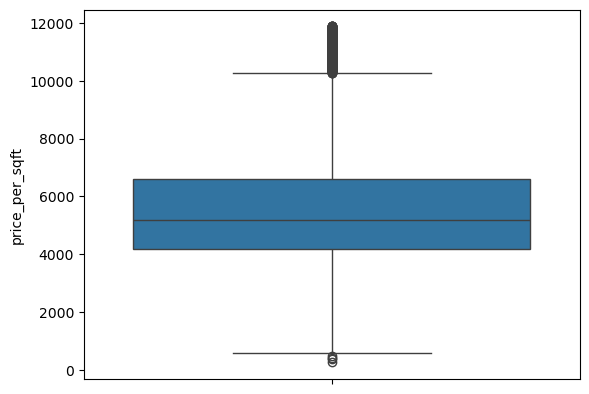

In [111]:
sns.boxplot(df_trimmed['price_per_sqft'])

In [113]:
# Removing outliers using Capping

capping_df = df.copy()
capping_df.loc[(capping_df['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit
capping_df.loc[(capping_df['price_per_sqft']<lower_limit), 'price_per_sqft'] = lower_limit

<Axes: ylabel='price_per_sqft'>

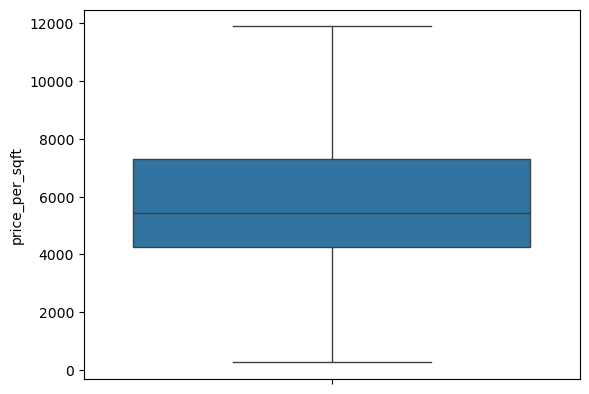

In [115]:
sns.boxplot(capping_df['price_per_sqft'])

In [ ]:
### Percetile Me